# **Coffee Production Prediction**

In [ ]:
earchCV

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report
# Importing Required Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridS

In [99]:
# load diffent data files

df_paths = [
    '/content/domestic-consumption.csv',
    '/content/exports-calendar-year.csv',
    '/content/exports-crop-year.csv',
    '/content/gross-opening-stocks.csv',
    '/content/total-production.csv'
]

In [100]:
dfs = [pd.read_csv(df_path) for df_path in df_paths]


In [101]:
def get_means(df):
    df = df.copy()
    countries = df[df.columns[0]]
    means = df.mean(axis=1)
    df = pd.concat([countries, means], axis=1)
    df.columns = ['country', countries.name]
    return df

In [102]:
def make_df(dfs):

    # Process all DataFrames
    processed_dfs = []

    for df in dfs:
        processed_dfs.append(get_means(df))

    # Merge DataFrames
    df = processed_dfs[0]

    for i in range(1, len(processed_dfs)):
        df = df.merge(processed_dfs[i], on='country')

    return df

In [103]:
def get_means(df):
    df = df.copy()
    countries = df[df.columns[0]]
    # Select only numeric columns before calculating the mean
    numeric_df = df.select_dtypes(include=np.number)
    means = numeric_df.mean(axis=1)
    df = pd.concat([countries, means], axis=1)
    df.columns = ['country', df.columns[1]] # Keep the original column name for the mean
    return df

Text(0.5, 1.0, 'Correlation among all the Variables of the Dataset')

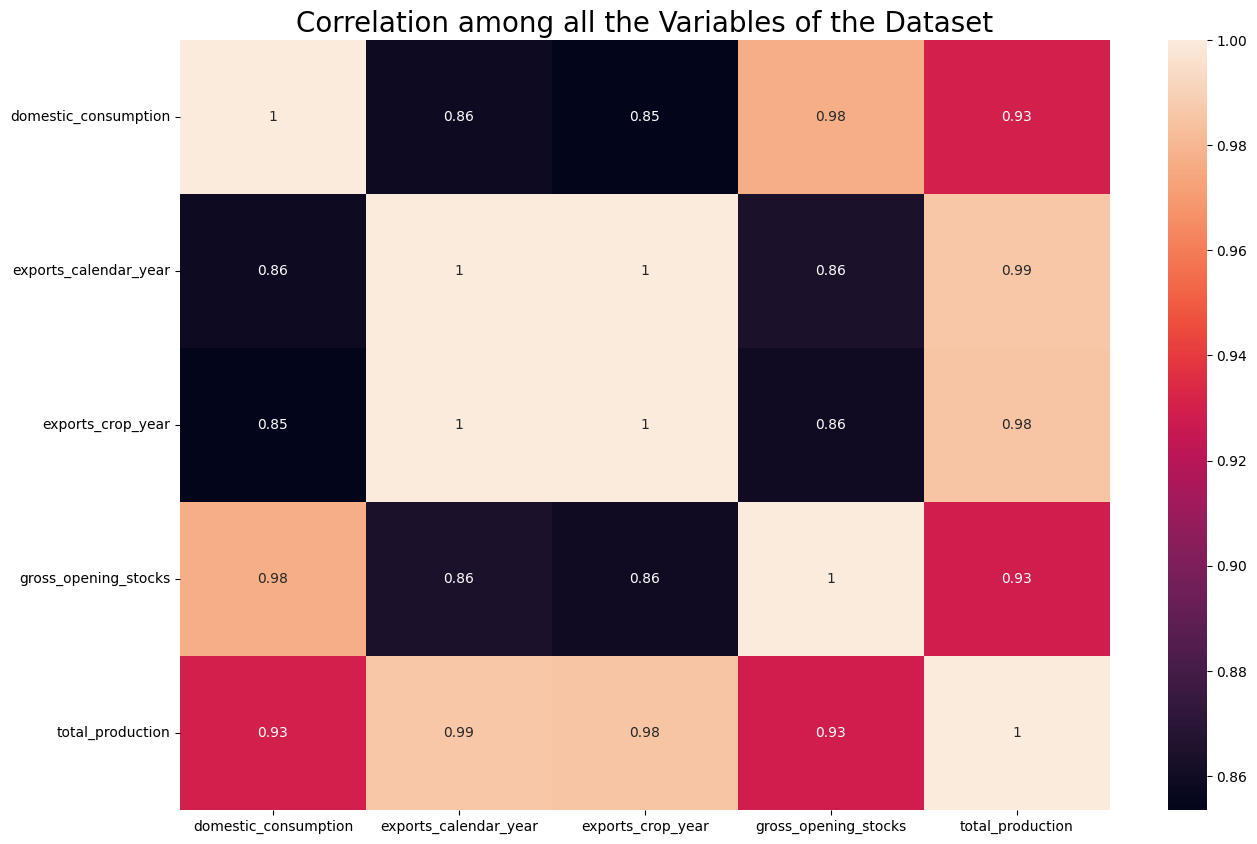

In [104]:
# Drop the 'country' column before calculating correlation
cor = data.drop('country', axis=1).corr()

#Checking relationship between variables
plt.figure(figsize=(15,10), facecolor='w')
sns.heatmap(cor,xticklabels=cor.columns,yticklabels=cor.columns,annot=True)
plt.title("Correlation among all the Variables of the Dataset", size=20)

In [105]:
data.shape

(56, 6)

In [106]:
data.isnull().sum()

,0
country,0
domestic_consumption,0
exports_calendar_year,0
exports_crop_year,0
gross_opening_stocks,0
total_production,0


In [107]:
data.duplicated().sum()

np.int64(0)

In [108]:
data.describe()


,domestic_consumption,exports_calendar_year,exports_crop_year,gross_opening_stocks,total_production
count,56.000000,56.000000,56.000000,56.000000,56.000000
mean,598.190822,1659.518787,1675.821731,649.819970,2209.623978
std,2081.814904,4089.426252,4148.578684,3109.283691,6018.038152
min,0.000000,0.063966,0.063966,0.000000,0.063966
25%,4.934638,30.332257,29.494833,4.586207,44.738335
50%,59.965517,173.106854,166.062226,39.224138,330.032916
75%,325.562914,1338.744688,1367.453200,157.386466,1499.984847
max,15234.310345,25706.195606,25919.128803,23213.206897,41067.783976


Text(0.5, 1.0, 'Correlation among all the Variables of the Dataset')

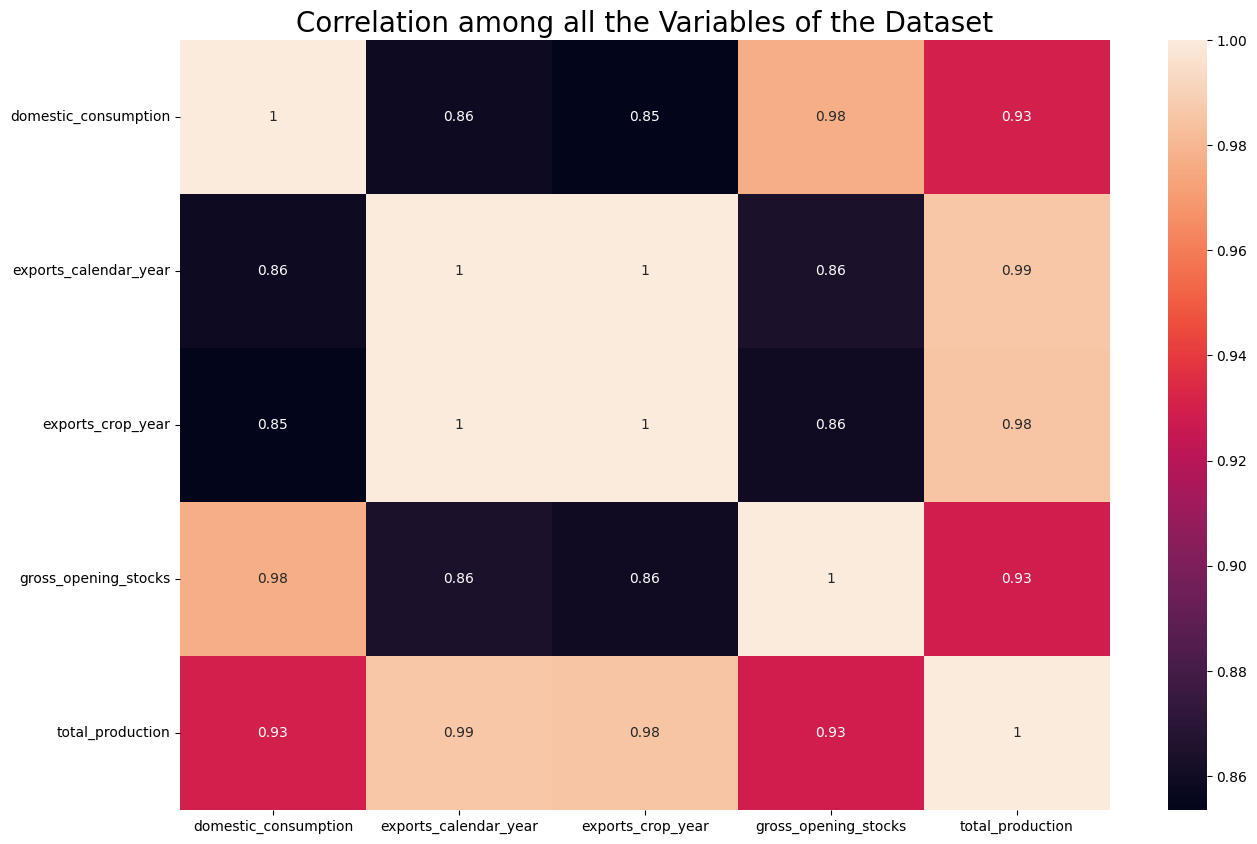

In [109]:
# Drop the 'country' column before calculating correlation
cor = data.drop('country', axis=1).corr()

#Checking relationship between variables
plt.figure(figsize=(15,10), facecolor='w')
sns.heatmap(cor,xticklabels=cor.columns,yticklabels=cor.columns,annot=True)
plt.title("Correlation among all the Variables of the Dataset", size=20)

Text(0.5, 1.0, 'Correlation among all the Variables of the Dataset')

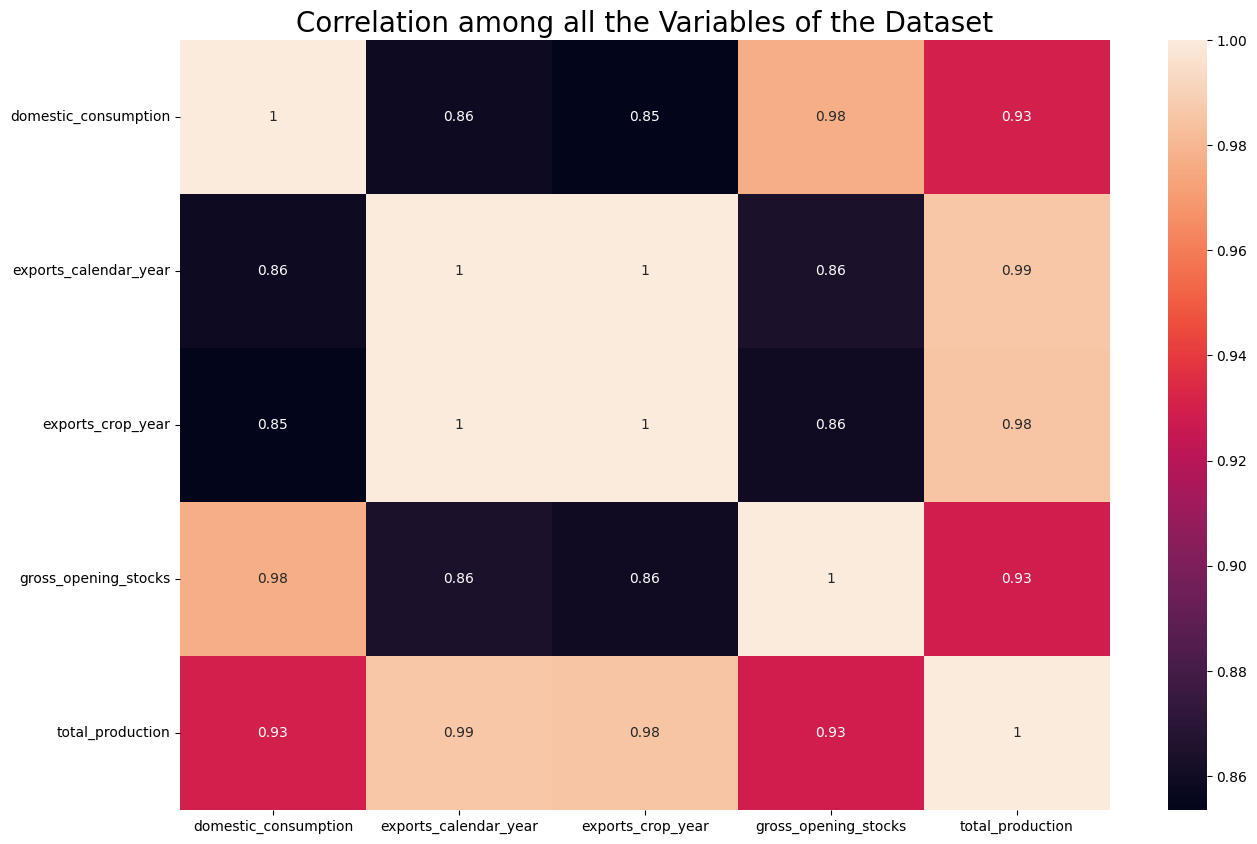

In [110]:

#Checking relationship between variables
plt.figure(figsize=(15,10), facecolor='w')
sns.heatmap(cor,xticklabels=cor.columns,yticklabels=cor.columns,annot=True)
plt.title("Correlation among all the Variables of the Dataset", size=20)


In [111]:
def preprocess_inputs(df):
    df = df.copy()

    # Drop country column
    df = df.drop('country', axis=1)

    # Split df into X and y
    y = df['total_production']
    X = df.drop('total_production', axis=1)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

    # Scale X
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

    return X_train, X_test, y_train, y_test

In [112]:
def get_means(df, name):
    df = df.copy()
    countries = df[df.columns[0]]
    # Select only numeric columns before calculating the mean
    numeric_df = df.select_dtypes(include=np.number)
    means = numeric_df.mean(axis=1)
    df = pd.concat([countries, means], axis=1)
    # Use the provided name for the mean column
    df.columns = ['country', name]
    return df

def make_df(dfs, df_paths):

    # Process all DataFrames with their corresponding names
    processed_dfs = []

    for i in range(len(dfs)):
        # Extract the name from the file path
        name = df_paths[i].split('/')[-1].split('.')[0].replace('-', '_')
        processed_dfs.append(get_means(dfs[i], name))

    # Merge DataFrames
    df = processed_dfs[0]

    for i in range(1, len(processed_dfs)):
        df = df.merge(processed_dfs[i], on='country')

    return df

# Re-run the dataframe creation with the modified function
data = make_df(dfs, df_paths)

# Now, call preprocess_inputs with the corrected data DataFrame
X_train, X_test, y_train, y_test = preprocess_inputs(data)

In [113]:
X_train


,domestic_consumption,exports_calendar_year,exports_crop_year,gross_opening_stocks
52,-0.288283,0.892275,0.873300,1.747068
35,-0.521580,-0.437099,-0.426357,-0.515553
26,-0.179496,0.702419,0.649249,1.699879
45,-0.468220,-0.434885,-0.424262,-0.514958
54,1.051480,5.195041,5.259387,2.681623
27,-0.218160,-0.248307,-0.263722,-0.441956
34,-0.454459,-0.340175,-0.332771,-0.458617
13,-0.521855,-0.403943,-0.395213,-0.476602
22,-0.405190,-0.094064,-0.124317,-0.123369
47,-0.520582,-0.416036,-0.407476,-0.484707


In [114]:
y_train


,total_production
52,3211.943759
35,5.872314
26,2658.525303
45,45.642441
54,15156.584548
27,589.295686
34,274.420314
13,75.645990
22,770.235855
47,48.227941


In [115]:
# Linear Regression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

lr_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(lr_rmse))

lr_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(lr_r2))

RMSE: 587.70
R^2: 0.99628


In [116]:
# Lasso Regression

model = Lasso(alpha=0.1, max_iter = 10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

lasso_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(lasso_rmse))

lasso_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(lasso_r2))

RMSE: 562.75
R^2: 0.99659


In [117]:
# Ridge Regression

'''params = {'alpha':[0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_reg = GridSearchCV(Ridge(), param_grid = params, cv = 5, scoring = 'r2')
ridge_reg.fit(X_train, y_train)
print(ridge_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
# Removed the 'normalize=False' argument as it is no longer valid in recent scikit-learn versions.
# The data is already scaled using StandardScaler.
model = Ridge(alpha=1, copy_X=True, fit_intercept=True, max_iter=None,
      random_state=None, solver='auto', tol=0.001)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ridg_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(ridg_rmse))

ridg_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(ridg_r2))

RMSE: 202.90
R^2: 0.99956


In [118]:
# Support Vector Regression

'''params = [{'C': [1,10,100,1000,10000], 'epsilon': [0.0001,0.001,0.01,0.1,1],
          'kernel': ['poly'], 'degree':[2,3,4]},
          {'C': [1,10,100,1000,10000], 'epsilon': [0.0001,0.001,0.01,0.1,1],
          'kernel': ['rbf']}]

svr_reg = GridSearchCV(SVR(),param_grid = params, scoring = 'r2', cv = 5)
svr_reg.fit(X_train, y_train)

print(svr_reg.best_estimator_)'''


# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = SVR(C=10000, cache_size=200, coef0=0.0, degree=3, epsilon=0.0001, gamma='scale',
            kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

sv_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(sv_rmse))

sv_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(sv_r2))

RMSE: 8643.10
R^2: 0.19579


In [119]:
# GradientBoostingRegressor

'''params = {'n_estimators': [50, 100, 200, 300],
          'max_depth': [8,10,12,14,16],
          'min_samples_split': [2,3,4],
          'subsample':[0.1, 0.2]}

gb_reg = GridSearchCV(GradientBoostingRegressor() ,param_grid = params, scoring = 'r2', cv = 5)
gb_reg.fit(X_train, y_train)

print(gb_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = GradientBoostingRegressor(alpha=0.9, ccp_alpha=0.0, criterion='friedman_mse',
                          init=None, learning_rate=0.1,
                          # Changed 'ls' to 'squared_error' as 'ls' is deprecated
                          loss='squared_error', max_depth=12,
                          max_features=None, max_leaf_nodes=None,
                          min_impurity_decrease=0.0,
                          min_samples_leaf=1, min_samples_split=3,
                          min_weight_fraction_leaf=0.0, n_estimators=200,
                          n_iter_no_change=None, # presort='deprecated', # Removed deprecated parameter
                          random_state=None, subsample=0.2, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

gb_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(gb_rmse))

gb_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(gb_r2))

RMSE: 6113.03
R^2: 0.59771


In [120]:
# Decision Tree Regression

'''params  = {'splitter': ['best', 'random'],'min_samples_leaf': [1, 2 ,3],
           'max_depth': [6,8,10,12,14,16,18]}

tree_reg = GridSearchCV(DecisionTreeRegressor(random_state = 0) ,param_grid = params, scoring = 'r2', cv = 5)
tree_reg.fit(X_train, y_train)

print(tree_reg.best_estimator_)'''

# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
# Changed 'mse' to 'squared_error' for the criterion parameter to be compatible with the current scikit-learn version.
model = DecisionTreeRegressor(ccp_alpha=0.0, criterion='squared_error', max_depth=8,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, # min_impurity_split=None, # Removed deprecated parameter
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, # Removed deprecated parameter 'presort'
                      random_state=0, splitter='best')

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

dt_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(dt_rmse))

dt_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(dt_r2))

RMSE: 6381.03
R^2: 0.56166


In [121]:
# BEST HYPERPARAMETERS FOR THE MODEL USING GRID SEARCH CV
model = RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='squared_error', # Changed 'mse' to 'squared_error'
                      max_depth=8, max_features=0.5, max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_samples_leaf=2,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=70, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rf_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(rf_rmse))

rf_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(rf_r2))

RMSE: 7965.19
R^2: 0.31700


## **Models Evaluation**

In [122]:
model_ev = pd.DataFrame({'Model': ['Linear Regression','Lasso Regression','Ridge Regression',
                                   'Support Vector Regression','Gradient Boosting Regressor','Decision Tree Regression','Random Forest Regression'],
                         'RMSE': [lr_rmse, lasso_rmse, ridg_rmse, sv_rmse, gb_rmse,
                                      dt_rmse, rf_rmse],
                         'R^2': [lr_r2, lasso_r2, ridg_r2, sv_r2, gb_r2, dt_r2, rf_r2]})
model_ev

,Model,RMSE,R^2
0,Linear Regression,587.702473,0.996282
1,Lasso Regression,562.750463,0.996591
2,Ridge Regression,202.901006,0.999557
3,Support Vector Regression,8643.103741,0.195790
4,Gradient Boosting Regressor,6113.031776,0.597706
5,Decision Tree Regression,6381.033368,0.561659
6,Random Forest Regression,7965.185325,0.316998


* From above data we see that for ridge model Root Mean Square Value is minimum and R2 Score is maximum.
* So we choose ridge model for our final prediction.

## **Prediction By Best Model**

In [123]:
# Ridge Regression

ridge_model = Ridge()

ridge_model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ridg_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print("RMSE: {:.2f}".format(ridg_rmse))

ridg_r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2))
print("R^2: {:.5f}".format(ridg_r2))


RMSE: 7965.19
R^2: 0.31700


In [124]:
ridge_model.predict([[40,1000,1000,100]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


array([2494322.02869545])